In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

print("CWD :", Path.cwd())
print("ROOT:", ROOT)
print("flux dir exists:", (ROOT / "data" / "flux").exists())



CWD : /home/administrator/XRF/notebooks
ROOT: /home/administrator/XRF
flux dir exists: True


In [3]:
from xrf_model.config import load_config
from xrf_model.pipeline import run_one_grid

cfg = load_config("configs/lab_xrf.yml")

# Replace with your flux file name once uploaded to data/flux/
flux_file = ROOT / "data" / "flux" / "spectrum_xraytube.txt"
print("flux exists:", flux_file.exists(), flux_file)

res_one = run_one_grid(flux_file, cfg, debugging=True)
res_one.keys()


flux exists: True /home/administrator/XRF/data/flux/spectrum_xraytube.txt
Active elements: ['O', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ti', 'Mn', 'Fe']
Grid: 2 × 2  (4 points, 4 valid)
SAMPLE: Ha
→ Saved to /home/administrator/XRF/results/lab_xrf/spectrum_xraytube_grid/spectrum_xraytube_Ha_grid_results.xlsx
→ Saved spectrum to /home/administrator/XRF/results/lab_xrf/spectrum_xraytube_grid/spectrum_xraytube_Ha_spectrum.xlsx
→ Saved PyMca file to /home/administrator/XRF/results/lab_xrf/spectrum_xraytube_grid/spectrum_xraytube_Ha_spectrum.dat
→ Saved MCA file (1633 channels, dE=30.0 eV/ch, live_time=1.0 s) to /home/administrator/XRF/results/lab_xrf/spectrum_xraytube_grid/spectrum_xraytube_Ha_spectrum.mca
→ Saved spectrum plot to /home/administrator/XRF/results/lab_xrf/spectrum_xraytube_grid/spectrum_xraytube_Ha_spectrum.png


dict_keys(['Ha'])

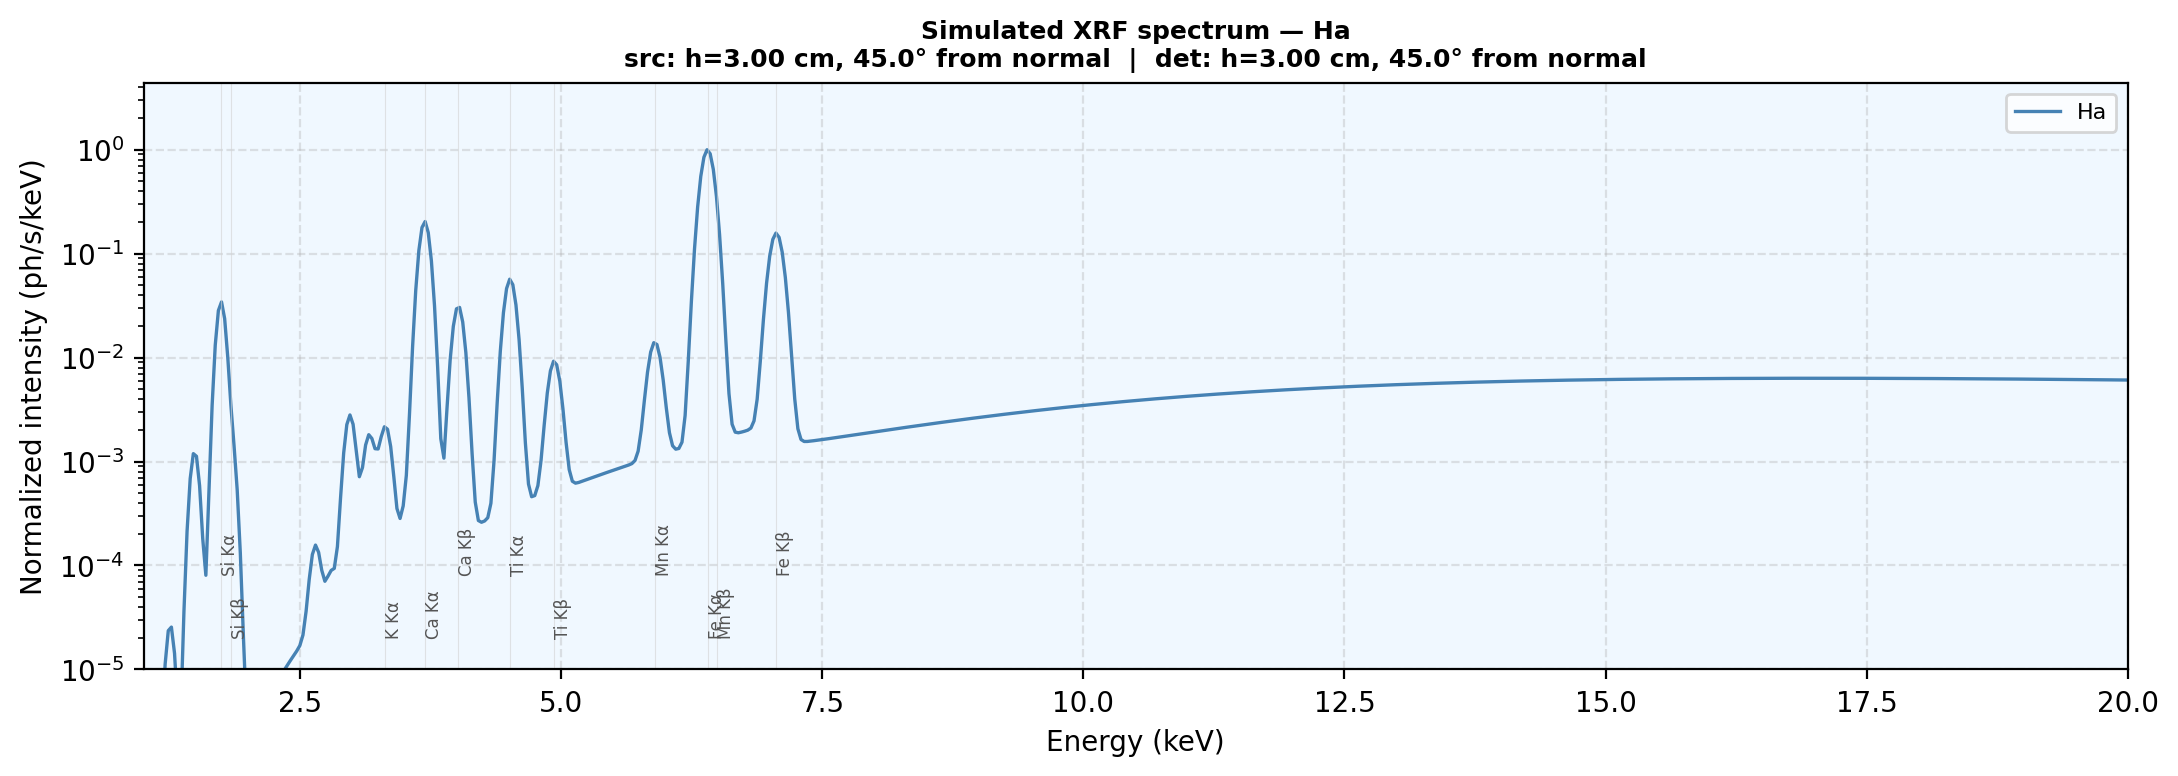

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from xrf_model import build_spectrum
from xrf_model.geometry import GridGeometry

MIN_LABEL_ENERGY_KEV = 1.5
INTENSITY_THRESHOLD  = 0.001
E_PLOT_MIN, E_PLOT_MAX = 1.0, 20.0  # keV

conc = "Ha"
r = res_one[conc]

spectrum = build_spectrum(
    r["energy"], r["I_coherent"], r["fluorescence"],
    be_mm         = cfg["be_window_mm"],
    si_active_um  = cfg["si_active_layer_um"],
    fano          = cfg["detector_fano"],
    enc_electrons = cfg["detector_enc_electrons"],
)

geo = GridGeometry(cfg)
src = geo.r_src
det = geo.r_det
src_angle = float(np.degrees(np.arctan2(np.sqrt(src[0]**2 + src[1]**2), src[2])))
det_angle = float(np.degrees(np.arctan2(np.sqrt(det[0]**2 + det[1]**2), det[2])))
geo_str = (
    f"src: h={src[2]:.2f} cm, {src_angle:.1f}° from normal  |  "
    f"det: h={det[2]:.2f} cm, {det_angle:.1f}° from normal"
)

spec_max = spectrum.max() if spectrum.max() > 0 else 1.0
spectrum_norm = np.maximum(spectrum / spec_max, 1e-30)

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor("aliceblue")
ax.semilogy(r["energy"], spectrum_norm, lw=1.2, color="steelblue", label=conc)
ax.set_xlim(E_PLOT_MIN, E_PLOT_MAX)
ax.set_ylim(bottom=1e-5) 
y_min, y_max = ax.get_ylim()

df_fluo = r["fluorescence"]
visible = df_fluo[
    np.isfinite(df_fluo["E_line_keV"]) &
    (df_fluo["Intensity_ph_s"] > 0) &
    (df_fluo["E_line_keV"] >= MIN_LABEL_ENERGY_KEV) &
    (df_fluo["E_line_keV"] <= E_PLOT_MAX)
]
if not visible.empty:
    i_max = visible["Intensity_ph_s"].max()
    visible = visible[visible["Intensity_ph_s"] >= INTENSITY_THRESHOLD * i_max]

label_y_positions = [y_min * 2.0, y_min * 8.0]
for i, (_, row) in enumerate(visible.iterrows()):
    E0 = row["E_line_keV"]
    ax.axvline(E0, color="lightgray", lw=0.4, alpha=0.6)
    ax.text(E0, label_y_positions[i % 2], f"{row['Element']} {row['Line']}",
            fontsize=6, va="bottom", rotation=90, color="#555555")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Normalized intensity (ph/s/keV)")
ax.set_title(f"Simulated XRF spectrum — {conc}\n{geo_str}", fontsize=9, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, which="major", alpha=0.35, linestyle="--")
plt.tight_layout()
plt.show()